<a href="https://colab.research.google.com/github/NikethnaSri-AI/Aanseaa_Technologies_Internship/blob/main/Task%203%20-%20CNN/transfer_learning(regularization).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from keras.utils import plot_model
from tensorflow.keras import models
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization
from keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, array_to_img, load_img
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_dir = '/content/drive/My Drive/brain_tumor_classification/Training'
test_dir = '/content/drive/My Drive/brain_tumor_classification/Testing'
categories = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

In [ ]:
image_paths_train = []
labels_train = []

In [ ]:
for category in categories:
    category_dir = os.path.join(train_dir, category)
    for filename in os.listdir(category_dir):
        if filename.endswith(".jpg") or filename.endswith(".png"):
            image_paths_train.append(os.path.join(category_dir, filename))
            labels_train.append(category)

In [ ]:
data = pd.DataFrame({
    'image_path': image_paths_train,
    'label': labels_train
})
print(data.head())

                                          image_path         label
0  /content/drive/My Drive/brain_tumor_classifica...  glioma_tumor
1  /content/drive/My Drive/brain_tumor_classifica...  glioma_tumor
2  /content/drive/My Drive/brain_tumor_classifica...  glioma_tumor
3  /content/drive/My Drive/brain_tumor_classifica...  glioma_tumor
4  /content/drive/My Drive/brain_tumor_classifica...  glioma_tumor


In [ ]:
train_data, val_data = train_test_split(data, test_size=0.2, stratify=data['label'])

In [ ]:
image_paths_test = []
labels_test = []
for category in categories:
    category_dir = os.path.join(test_dir, category)
    for filename in os.listdir(category_dir):
        if filename.endswith(".jpg") or filename.endswith(".png"):
            image_paths_test.append(os.path.join(category_dir, filename))
            labels_test.append(category)
data_test = pd.DataFrame({
    'image_path': image_paths_test,
    'label': labels_test
})
print(data_test.head())

                                          image_path         label
0  /content/drive/My Drive/brain_tumor_classifica...  glioma_tumor
1  /content/drive/My Drive/brain_tumor_classifica...  glioma_tumor
2  /content/drive/My Drive/brain_tumor_classifica...  glioma_tumor
3  /content/drive/My Drive/brain_tumor_classifica...  glioma_tumor
4  /content/drive/My Drive/brain_tumor_classifica...  glioma_tumor


In [ ]:
print(len(labels_train))
print(len(labels_test))

2870
394


In [ ]:
print(f"Training images: {len(train_data)}")
print(f"Validation images: {len(val_data)}")
print(f"Test images: {len(data_test)}")

Training images: 2296
Validation images: 574
Test images: 394


In [ ]:
image_size = (150, 150)
batch_size = 32
image_shape = (150, 150, 3)
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_data,
    x_col='image_path',
    y_col='label',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical')

validation_generator = val_datagen.flow_from_dataframe(
    dataframe=val_data,
    x_col='image_path',
    y_col='label',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical')

test_generator = test_datagen.flow_from_dataframe(
    dataframe=data_test,
    x_col='image_path',
    y_col='label',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False)

Found 2296 validated image filenames belonging to 4 classes.
Found 574 validated image filenames belonging to 4 classes.
Found 394 validated image filenames belonging to 4 classes.


In [ ]:
vgg16 = VGG16(weights='imagenet', include_top=False, input_shape=image_shape)
for layer in vgg16.layers:
    layer.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
x = vgg16.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu',kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu',kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
predictions = Dense(len(categories), activation='softmax')(x)
model = Model(inputs=vgg16.input, outputs=predictions)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 150, 150, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 150, 150, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 75, 75, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 75, 75, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 75, 75, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 37, 37, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 37, 37, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 37, 37, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 37, 37, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 18, 18, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 18, 18, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 18, 18, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 18, 18, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 9, 9, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 9, 9, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 9, 9, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 9, 9, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 4, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         262,6

 Total params: 15,112,772 (57.65 MB)

 Trainable params: 396,548 (1.51 MB)

 Non-trainable params: 14,716,224 (56.14 MB)

In [ ]:
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
early_stopping = EarlyStopping(patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(factor=0.5, patience=5)
checkpoint = ModelCheckpoint('best_vgg16_model.keras', save_best_only=True)
print(f"Total training samples: {train_generator.samples}")
print(f"Batch size: {batch_size}")
print(f"Steps per epoch: {train_generator.samples // batch_size}")


Total training samples: 2296
Batch size: 32
Steps per epoch: 71


In [ ]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    callbacks=[early_stopping, reduce_lr, checkpoint]
)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


72/72 ━━━━━━━━━━━━━━━━━━━━ 787s 10s/step - accuracy: 0.5546 - loss: 8.1245 - val_accuracy: 0.6562 - val_loss: 5.0193 - learning_rate: 0.0010
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.7554 - loss: 4.4380

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


72/72 ━━━━━━━━━━━━━━━━━━━━ 608s 8s/step - accuracy: 0.7555 - loss: 4.4351 - val_accuracy: 0.5667 - val_loss: 4.0285 - learning_rate: 0.0010
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 726s 10s/step - accuracy: 0.8024 - loss: 3.4779 - val_accuracy: 0.5827 - val_loss: 3.4188 - learning_rate: 0.0010
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 593s 8s/step - accuracy: 0.8237 - loss: 2.9070 - val_accuracy: 0.5667 - val_loss: 3.0431 - learning_rate: 0.0010
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 745s 10s/step - accuracy: 0.8126 - loss: 2.4980 - val_accuracy: 0.8640 - val_loss: 2.1614 - learning_rate: 0.0010
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 646s 8s/step - accuracy: 0.8191 - loss: 2.1398 - val_accuracy: 0.9000 - val_loss: 1.7723 - learning_rate: 0.0010
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 681s 9s/step - accuracy: 0.8271 - loss: 1.8241 - val_accuracy: 0.8438 - val_loss: 1.6423 - learning_rate: 0.0010
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 568s 8s/step - accuracy: 0.8622 - loss: 1.5766 - val_accuracy: 0.

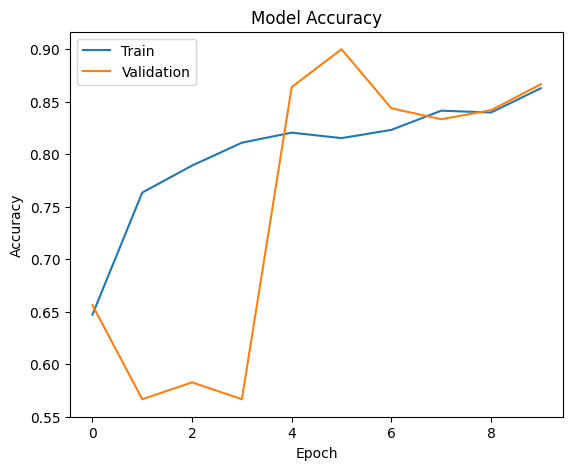

In [ ]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')


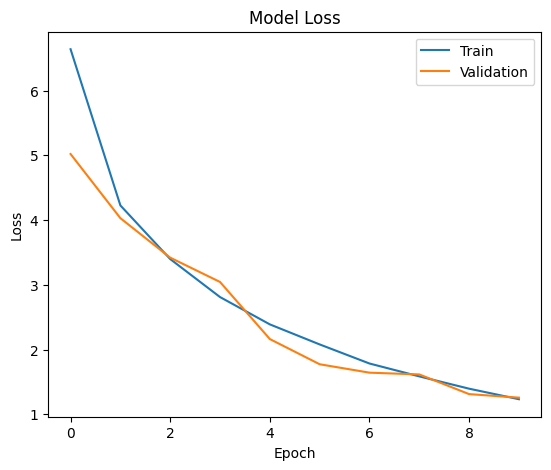

In [ ]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

In [ ]:
loss, accuracy = model.evaluate(test_generator, steps=test_generator.samples // batch_size)
print(f"Test Loss: {loss:0.5f}")
print(f"Test Accuracy: {accuracy:0.5f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 97s 8s/step - accuracy: 0.4367 - loss: 3.5868
Test Loss: 2.59669
Test Accuracy: 0.52604


13/13 ━━━━━━━━━━━━━━━━━━━━ 99s 7s/step


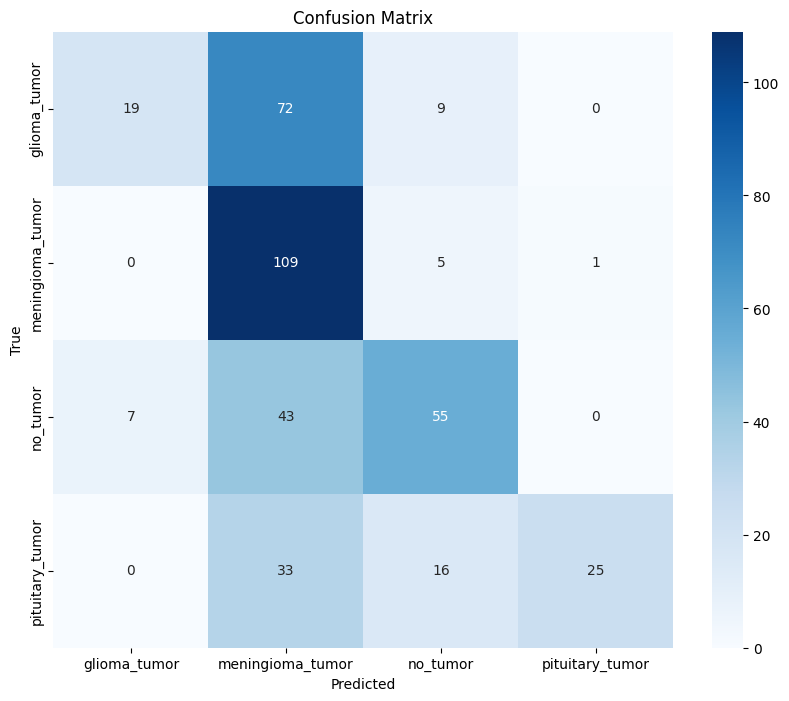

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
test_generator.reset()
predictions = model.predict(test_generator, steps=test_generator.samples // batch_size + 1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print("Classification Report:")
print(report)

Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.73      0.19      0.30       100
meningioma_tumor       0.42      0.95      0.59       115
        no_tumor       0.65      0.52      0.58       105
 pituitary_tumor       0.96      0.34      0.50        74

        accuracy                           0.53       394
       macro avg       0.69      0.50      0.49       394
    weighted avg       0.66      0.53      0.50       394



In [ ]:
from PIL import Image
import io
import ipywidgets as widgets
from IPython.display import display

FileUpload(value={}, accept='image/*', description='Upload')

Button(description='Predict', style=ButtonStyle())

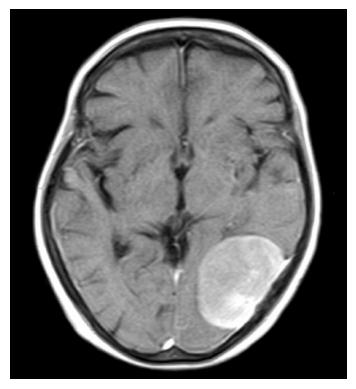

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step
The Model predicts that it is a No Tumor


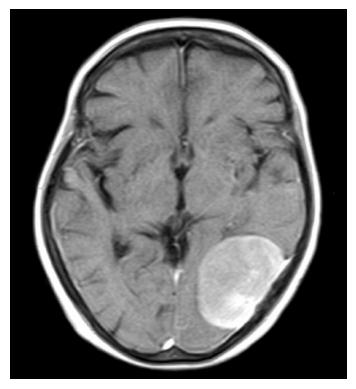

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step
The Model predicts that it is a No Tumor


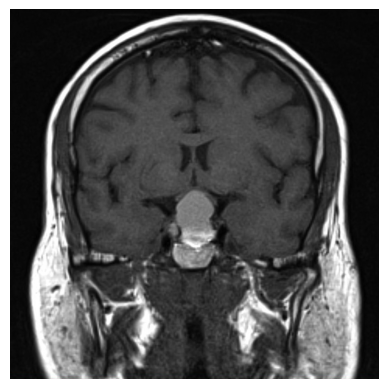

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
The Model predicts that it is a No Tumor


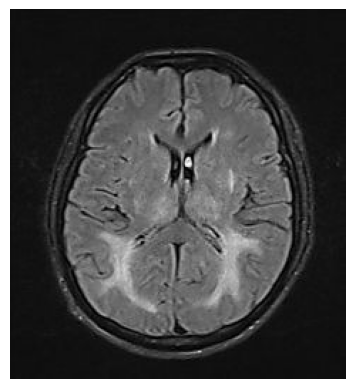

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
The Model predicts that it is a Meningioma Tumor


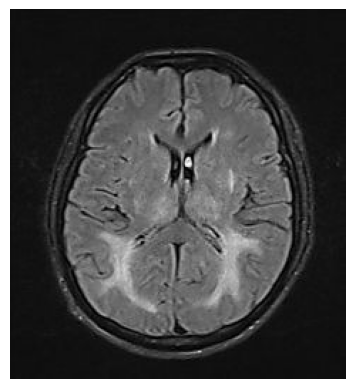

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
The Model predicts that it is a Meningioma Tumor


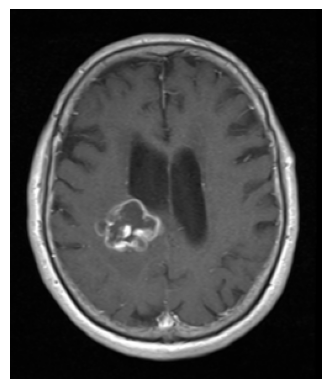

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
The Model predicts that it is a No Tumor


In [ ]:
def img_pred(upload):
    for name, file_info in upload.value.items():
        img = Image.open(io.BytesIO(file_info['content']))
        plt.imshow(img)
        plt.axis('off')
        plt.show()
        img = img.convert('RGB')
        img = img.resize((150, 150))
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0
        p = model.predict(img_array)
        p = np.argmax(p, axis=1)[0]
        categories = ['Glioma Tumor', 'No Tumor', 'Meningioma Tumor', 'Pituitary Tumor']
        prediction = categories[p]
        print(f'The Model predicts that it is a {prediction}')

uploader = widgets.FileUpload(accept='image/*', multiple=False)
display(uploader)
predict_button = widgets.Button(description="Predict")
display(predict_button)
def on_predict_button_clicked(b):
    if uploader.value:
        img_pred(uploader)
    else:
        print("Please upload an image first.")
predict_button.on_click(on_predict_button_clicked)
